# 2. Предобработка и разбиение данных

## Этапы
1. Разбиение на train/test с сохранением баланса (80/20)
2. Удаление соли и перца (heuristic denoising)
3. Балансировка классов через аугментации

In [1]:
import sys
sys.path.append("..")

from src.config import CSV_PATH, IMAGES_DIR, DATA_PROCESSED_80_20, SEED, DATA_PROCESSED_90_10
from src.datasets import create_balanced_split, balance_deepfake_dataset, show_dataset_counts
from src.utils import set_seed

set_seed(SEED)




create_balanced_split(
    csv_path=str(CSV_PATH),
    images_dir=str(IMAGES_DIR),
    out_dir=str(DATA_PROCESSED_80_20),
    train_ratio=0.8,
    overwrite=True
)

create_balanced_split(
    csv_path=str(CSV_PATH),
    images_dir=str(IMAGES_DIR),
    out_dir=str(DATA_PROCESSED_90_10),
    train_ratio=0.9,
    seed=SEED,
    overwrite=True,
)

файлов на диске: 20
строк в CSV:     50000
совпало:         20
Класс 0: train=10, test=3
Класс 1: train=5, test=2
Готово: /Users/the_alive/ALL_PYTHON_PROJECTS/GAN_detection/data/processed/clean_80_20
файлов на диске: 20
строк в CSV:     50000
совпало:         20
Класс 0: train=11, test=2
Класс 1: train=6, test=1
Готово: /Users/the_alive/ALL_PYTHON_PROJECTS/GAN_detection/data/processed/clean_90_10


In [2]:
show_dataset_counts(str(DATA_PROCESSED_80_20 / "train_dataset"),
                    str(DATA_PROCESSED_80_20 / "test_dataset"))
show_dataset_counts(str(DATA_PROCESSED_90_10 / "train_dataset"),
                    str(DATA_PROCESSED_90_10 / "test_dataset"))

      Train      
real: 10
fake: 5
      Test      
real: 3
fake: 2
      Train      
real: 11
fake: 6
      Test      
real: 2
fake: 1


## Балансировка через аугментации

In [3]:
train_real = DATA_PROCESSED_80_20 / "train_dataset" / "0"
train_fake = DATA_PROCESSED_80_20 / "train_dataset" / "1"

if len(list(train_real.iterdir())) != len(list(train_fake.iterdir())):
    balance_deepfake_dataset(str(train_real), str(train_fake))
else:
    print("Классы уже сбалансированы")

show_dataset_counts(str(DATA_PROCESSED_80_20 / "train_dataset"), str(DATA_PROCESSED_80_20 / "test_dataset"))

Итог: real=0, fake=0
      Train      
real: 10
fake: 5
      Test      
real: 3
fake: 2


In [4]:
train_real = DATA_PROCESSED_90_10 / "train_dataset" / "0"
train_fake = DATA_PROCESSED_90_10 / "train_dataset" / "1"

if len(list(train_real.iterdir())) != len(list(train_fake.iterdir())):
    balance_deepfake_dataset(str(train_real), str(train_fake))
else:
    print("Классы уже сбалансированы")

show_dataset_counts(str(DATA_PROCESSED_90_10 / "train_dataset"), str(DATA_PROCESSED_90_10 / "test_dataset"))

Итог: real=0, fake=0
      Train      
real: 11
fake: 6
      Test      
real: 2
fake: 1


## Очистка шума (salt and pepper)

Пробовали UNet и ResNet-денойзеры, но лучший результат дал простой
heuristic-метод: заменяем пиксели, отличающиеся от медианы, на медианное значение

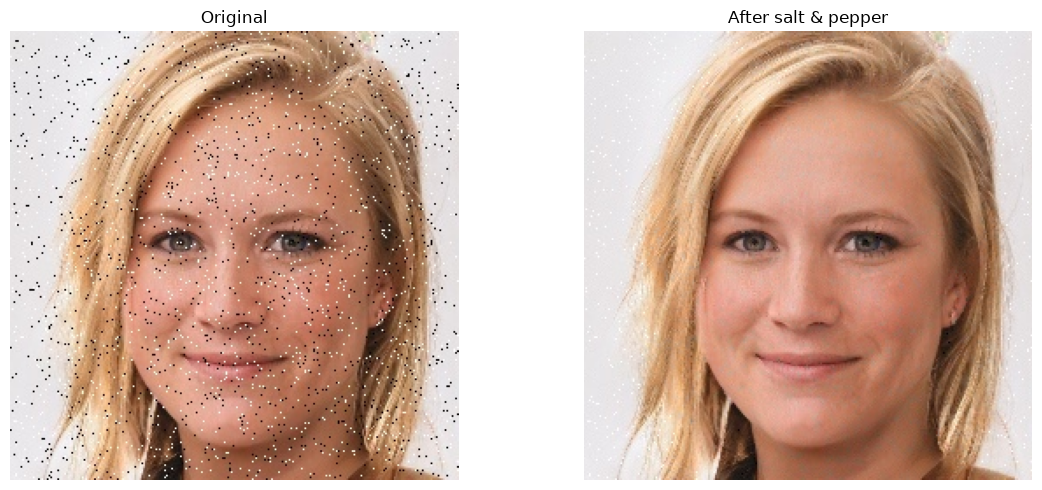

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.datasets import remove_salt_and_pepper

img_path = IMAGES_DIR / "2.jpg"
img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
clean = remove_salt_and_pepper(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(clean); axes[1].set_title("After salt & pepper"); axes[1].axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/salt_pepper.png", dpi=150, bbox_inches="tight")
plt.show()